# Tarang v9.2 — Quantitative Label-Noise Analysis

## Why this notebook exists

v9.1's Phase E asked you to visually categorize 60 ECG beats as underfitting / ambiguous / label_noise / clipped_context. **That was the wrong approach.** Categorizing ECG beats requires cardiology training — the ability to identify P-wave morphology, distinguish atrial from junctional from sinus beats, and judge prematurity in context. The contact sheet format made it impossible even with training (P-waves aren't visible at thumbnail resolution).

**This notebook uses the data we already have instead of your eyes.**

## The core insight

A supraventricular ectopic beat (S) is **by definition premature** — it fires before the next expected sinus beat. The RR features we computed for every beat include:

- `prematurity_index = rr_prev / rr_mean_5` — how early this beat came relative to the local average
- `compensatory_ratio = rr_next / rr_mean_5` — the pause after the beat

If a beat is annotated S but has `prematurity_index ≈ 1.0`, it came exactly on time. **It is not premature. It is probably not S.** No visual inspection needed — the RR interval is an objective measurement.

## What this notebook does

1. **Pulls raw annotation symbols** from MIT-BIH .atr files (before AAMI mapping). The mapping `A, a, J, S → 'S'` lumps together atrial premature beats (genuinely premature) with junctional beats (which can be non-premature escape rhythms).

2. **Flags likely label noise quantitatively**: any "S" beat with `prematurity_index > 0.95` is flagged as suspicious. The threshold is conservative — real atrial premature beats typically have `prematurity_index < 0.85`.

3. **Shows per-patient breakdown**: which patients have the most suspicious "S" beats, and what raw symbols those beats carry.

4. **Re-evaluates v9 on cleaned S sets**: excludes likely-noise beats and recomputes S F1. If S F1 jumps, the model was never the problem — the labels were.

5. **No cardiology knowledge required from you.** The RR interval does the work.


## Setup — load v9 models, data, and raw annotations

In [1]:
import os, json, glob, warnings
from collections import Counter, defaultdict
from datetime import datetime

import wfdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import regularizers
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score
from scipy.signal import resample_poly

warnings.filterwarnings('ignore')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset'
def find_dir(base, *candidates):
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p): return p
    for c in candidates:
        for v in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, v)
            if os.path.isdir(p): return p
    return os.path.join(base, candidates[0])

MITBIH_PATH = find_dir(BASE, 'mit-bih-arrhythmia-database-1.0.0', 'mitbih')
OUTPUTS_V9  = 'outputs_v9'
OUTPUTS_V92 = 'outputs_v92'
os.makedirs(OUTPUTS_V92, exist_ok=True)

SOURCE_FS, TARGET_FS = 360, 250
WINDOW_LEN = 130
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

BEAT_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V','F':'V',
    '/':'Q','f':'Q','Q':'Q',
}
CLASSES_TO_USE = ['N','S','V']
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
] if r not in MITBIH_TEST_RECORDS and r not in MITBIH_VAL_RECORDS]

# ── Load v9 data checkpoint ──────────────────────────────────────────────────
cp = np.load(f'{OUTPUTS_V9}/data_checkpoint.npz', allow_pickle=True)
mb_beats, mb_rr = cp['mb_beats'], cp['mb_rr']
mb_labels, mb_recs = cp['mb_labels'], cp['mb_recs']
sv_beats, sv_rr = cp['sv_beats'], cp['sv_rr']
sv_labels, sv_recs = cp['sv_labels'], cp['sv_recs']

X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])
le = LabelEncoder(); le.fit(CLASSES_TO_USE)
y_all = le.transform(y_raw_all)
n_idx = int(np.where(le.classes_=='N')[0][0])
s_idx = int(np.where(le.classes_=='S')[0][0])
v_idx = int(np.where(le.classes_=='V')[0][0])

test_recs_set = {f'mitbih_{r}' for r in MITBIH_TEST_RECORDS}
test_mask = np.isin(recs_all, list(test_recs_set))
X_test = X_all[test_mask]; X_rr_test = X_rr_all[test_mask]
y_test = y_all[test_mask]; recs_test = recs_all[test_mask]
y_test_raw = y_raw_all[test_mask]

RR_MEAN = X_rr_all[~test_mask & ~np.isin(recs_all, [f'mitbih_{r}' for r in MITBIH_VAL_RECORDS])].mean(axis=0)
RR_STD = X_rr_all[~test_mask & ~np.isin(recs_all, [f'mitbih_{r}' for r in MITBIH_VAL_RECORDS])].std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8
X_rr_test_norm = (X_rr_test - RR_MEAN) / RR_STD

# ── Load v9 models ───────────────────────────────────────────────────────────
def build_gate_model(ecg_shape=(130,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((130,2,1))(ecg_in)
    for f,k,d in [(16,7,0.1),(32,5,0.1),(64,5,0.15),(64,3,0.0)]:
        x = tf.keras.layers.Conv2D(f,(k,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if k >= 5: x = tf.keras.layers.MaxPooling2D((2,1))(x); x = tf.keras.layers.SpatialDropout2D(d)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(r)
    m = tf.keras.layers.Concatenate()([x, r])
    m = tf.keras.layers.Dense(32, use_bias=False)(m)
    m = tf.keras.layers.BatchNormalization()(m)
    m = tf.keras.layers.Activation('relu')(m)
    m = tf.keras.layers.Dropout(0.35)(m)
    return tf.keras.Model(inputs=[ecg_in,rr_in],
                           outputs=tf.keras.layers.Dense(1,activation='sigmoid')(m))

def build_sv_model(ecg_shape=(130,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((130,2,1))(ecg_in)
    for f,k,d in [(16,7,0.1),(32,5,0.1),(48,5,0.15),(48,3,0.0)]:
        x = tf.keras.layers.Conv2D(f,(k,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if k >= 5: x = tf.keras.layers.MaxPooling2D((2,1))(x); x = tf.keras.layers.SpatialDropout2D(d)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(r)
    m = tf.keras.layers.Concatenate()([x, r])
    m = tf.keras.layers.Dense(32, use_bias=False)(m)
    m = tf.keras.layers.BatchNormalization()(m)
    m = tf.keras.layers.Activation('relu')(m)
    m = tf.keras.layers.Dropout(0.35)(m)
    v = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(m)
    s = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(m)
    return tf.keras.Model(inputs=[ecg_in,rr_in], outputs=[v,s])

gate_model = tf.keras.models.load_model(f'{OUTPUTS_V9}/tarang_gate_v8_7.keras', compile=False)
sv_model = tf.keras.models.load_model(f'{OUTPUTS_V9}/sv_loop2_nshare0.50.keras', compile=False)
V9_GATE_THR, V9_V_THR, V9_S_THR = 0.700, 0.40, 0.50

print(f"Loaded v9 models. Test S beats: {int(np.sum(y_test==s_idx))}")


Loaded v9 models. Test S beats: 961


## Step 1 — Pull raw annotation symbols for every test S beat

The AAMI mapping lumps 4 different raw symbols into the 'S' class:
- `A` — atrial premature beat (genuinely premature, this is the "real" S)
- `a` — aberrated atrial premature beat (genuinely premature)
- `J` — junctional beat (can be premature OR escape — escape beats are NOT premature)
- `S` — supraventricular premature beat (vague annotation, often premature)

If a patient's "S" beats are mostly `J` (junctional), the non-premature RR pattern is explained — junctional escape beats fire at the AV junction's intrinsic rate when the SA node drops out, so they're not premature. They're rhythmically different from atrial ectopy but get mapped to the same AAMI class.

This step re-reads every test record's .atr file and records the raw symbol for each S beat.

In [2]:
# ── Re-read raw annotations for test records ─────────────────────────────────
# For each test S beat in our array, find its raw annotation symbol
print("Pulling raw annotation symbols for test S beats...")

raw_sym_per_beat = {}  # (record, beat_index_in_record) -> raw symbol
rec_beat_idx = {}      # record -> list of beat indices that are S in our array

for rec_id in MITBIH_TEST_RECORDS:
    rec_str = str(rec_id)
    rec_tag = f'mitbih_{rec_str}'
    try:
        ann = wfdb.rdann(f'{MITBIH_PATH}/{rec_str}', 'atr')
        # For each annotation, check if it maps to S in AAMI
        for k, sym in enumerate(ann.symbol):
            if sym in BEAT_MAP and BEAT_MAP[sym] == 'S':
                sample = ann.sample[k]
                raw_sym_per_beat[(rec_tag, k)] = sym
    except Exception as e:
        print(f"  [skip] {rec_tag}: {e}")

# Now match our array beats to raw annotations
# Our array indices for S beats in test:
s_test_mask = y_test_raw == 'S'
s_test_indices = np.where(s_test_mask)[0]
s_test_recs = recs_test[s_test_mask]

# Build a per-record S-beat list to match against raw annotations
# (our array preserves per-record beat order, so the k-th S beat in our array
#  for a record corresponds to the k-th AAMI-S annotation for that record)
raw_syms_for_test_s = []
for idx in s_test_indices:
    rec_tag = recs_test[idx]
    # Count how many S beats came before this one in the same record
    s_beats_in_rec = np.where(recs_test == rec_tag)[0]
    s_beats_before = np.sum(s_beats_in_rec <= idx)
    # s_beats_before is 1-indexed position of this S beat within the record's S beats
    key = (rec_tag, s_beats_before - 1)
    # Actually we need to match by order — let's use a simpler approach
    raw_syms_for_test_s.append(None)

# Simpler approach: for each test record, get the list of raw S-type symbols in order
print("\nRaw annotation symbols per test record (S-class beats only):")
rec_raw_syms = {}
for rec_id in MITBIH_TEST_RECORDS:
    rec_str = str(rec_id)
    rec_tag = f'mitbih_{rec_str}'
    try:
        ann = wfdb.rdann(f'{MITBIH_PATH}/{rec_str}', 'atr')
        syms = [sym for sym in ann.symbol if sym in BEAT_MAP and BEAT_MAP[sym] == 'S']
        if syms:
            rec_raw_syms[rec_tag] = syms
            print(f"  {rec_tag}: {len(syms)} S beats, raw symbols: {Counter(syms)}")
    except Exception as e:
        pass

# Match raw symbols to our array beats by order within each record
raw_sym_array = np.array([''] * len(y_test), dtype=object)
for rec_tag in set(recs_test):
    if rec_tag not in rec_raw_syms: continue
    syms = rec_raw_syms[rec_tag]
    rec_s_mask = (recs_test == rec_tag) & (y_test_raw == 'S')
    rec_s_indices = np.where(rec_s_mask)[0]
    for i, idx in enumerate(rec_s_indices):
        if i < len(syms):
            raw_sym_array[idx] = syms[i]

# Summary
s_mask = y_test_raw == 'S'
print(f"\n{'='*70}")
print(f"RAW ANNOTATION SYMBOL DISTRIBUTION FOR TEST S BEATS")
print(f"{'='*70}")
print(f"Total test S beats: {int(s_mask.sum())}")
raw_sym_counts = Counter(raw_sym_array[s_mask])
print(f"\nRaw symbol counts:")
for sym, count in sorted(raw_sym_counts.items(), key=lambda x: -x[1]):
    pct = count / s_mask.sum() * 100
    print(f"  '{sym}' : {count:5d}  ({pct:.1f}%)")


Pulling raw annotation symbols for test S beats...

Raw annotation symbols per test record (S-class beats only):
  mitbih_101: 3 S beats, raw symbols: Counter({'A': 3})
  mitbih_108: 4 S beats, raw symbols: Counter({'A': 4})
  mitbih_112: 2 S beats, raw symbols: Counter({'A': 2})
  mitbih_114: 12 S beats, raw symbols: Counter({'A': 10, 'J': 2})
  mitbih_116: 1 S beats, raw symbols: Counter({'A': 1})
  mitbih_118: 96 S beats, raw symbols: Counter({'A': 96})
  mitbih_201: 128 S beats, raw symbols: Counter({'a': 97, 'A': 30, 'J': 1})
  mitbih_202: 55 S beats, raw symbols: Counter({'A': 36, 'a': 19})
  mitbih_203: 2 S beats, raw symbols: Counter({'a': 2})
  mitbih_205: 3 S beats, raw symbols: Counter({'A': 3})
  mitbih_207: 107 S beats, raw symbols: Counter({'A': 107})
  mitbih_208: 2 S beats, raw symbols: Counter({'S': 2})
  mitbih_209: 383 S beats, raw symbols: Counter({'A': 383})
  mitbih_210: 22 S beats, raw symbols: Counter({'a': 22})
  mitbih_219: 7 S beats, raw symbols: Counter({'A'

## Step 2 — Quantitative label-noise flagging via prematurity index

**Definition:** `prematurity_index = rr_prev / rr_mean_5`

- `< 0.85` → genuinely premature (this is what S beats should look like)
- `0.85 – 0.95` → mildly premature (borderline, could be real S)
- `0.95 – 1.05` → NOT premature (suspicious — likely label noise or junctional escape)
- `> 1.05` → late (escape rhythm, NOT ectopic — should not be S)

A real atrial premature beat (A) typically has `prematurity_index < 0.85`. If a beat annotated S has `prematurity_index > 0.95`, it came on time — it is not premature, and by definition not a supraventricular ectopic beat.

**No visual inspection required.** The RR interval is an objective measurement.

In [3]:
# ── Compute prematurity-based label noise flags ─────────────────────────────
s_mask = y_test_raw == 'S'
s_indices = np.where(s_mask)[0]
premat = X_rr_test[s_mask, 6]  # prematurity_index is column 6
comp_ratio = X_rr_test[s_mask, 5]  # compensatory_ratio is column 5

# Categorize
def premat_category(pi):
    if pi < 0.85: return 'genuinely_premature'  # real S
    elif pi < 0.95: return 'mildly_premature'    # borderline
    elif pi <= 1.05: return 'not_premature'      # suspicious
    else: return 'late_escape'                    # definitely not S

categories = np.array([premat_category(p) for p in premat])

print(f"{'='*70}")
print(f"PREMATURITY-BASED LABEL NOISE ANALYSIS (test S beats, n={len(premat)})")
print(f"{'='*70}")
print(f"\nCategory counts:")
cat_counts = Counter(categories)
for cat in ['genuinely_premature', 'mildly_premature', 'not_premature', 'late_escape']:
    n = cat_counts.get(cat, 0)
    pct = n / len(premat) * 100
    print(f"  {cat:<25}: {n:4d}  ({pct:5.1f}%)")

n_suspicious = cat_counts.get('not_premature', 0) + cat_counts.get('late_escape', 0)
print(f"\n  Suspicious (not_premature + late_escape): {n_suspicious}/{len(premat)} = {n_suspicious/len(premat)*100:.1f}%")
print(f"  → If >30% of 'S' beats are not premature, label noise is a major factor.")

# Cross-tab: raw symbol × prematurity category
print(f"\n{'='*70}")
print(f"RAW SYMBOL × PREMATURITY CATEGORY")
print(f"{'='*70}")
raw_syms = raw_sym_array[s_mask]
ct = pd.crosstab(pd.Series(raw_syms, name='raw_symbol'),
                  pd.Series(categories, name='prematurity_category'),
                  margins=True)
print(ct)

# Per-patient breakdown
print(f"\n{'='*70}")
print(f"PER-PATIENT S BEAT ANALYSIS")
print(f"{'='*70}")
print(f"{'Patient':<14} {'n_S':>5} {'genuinely':>10} {'mildly':>8} {'not_prem':>9} {'escape':>8} {'mean_premat':>12} {'raw_syms':>20}")
print(f"{'-'*90}")
for rec_tag in sorted(set(recs_test[s_mask])):
    rec_s_local = np.where((recs_test == rec_tag) & s_mask)[0]
    if len(rec_s_local) == 0: continue
    rec_premat = premat[np.isin(s_indices, rec_s_local)]
    rec_cats = categories[np.isin(s_indices, rec_s_local)]
    rec_raw = raw_syms[np.isin(s_indices, rec_s_local)]
    n = len(rec_s_local)
    g = np.sum(rec_cats == 'genuinely_premature')
    m = np.sum(rec_cats == 'mildly_premature')
    np_ = np.sum(rec_cats == 'not_premature')
    e = np.sum(rec_cats == 'late_escape')
    mp = rec_premat.mean()
    rs = dict(Counter(rec_raw))
    rs_str = str(rs)
    print(f"{rec_tag:<14} {n:>5} {g:>10} {m:>8} {np_:>9} {e:>8} {mp:>12.3f} {rs_str:>20}")


PREMATURITY-BASED LABEL NOISE ANALYSIS (test S beats, n=961)

Category counts:
  genuinely_premature      :  451  ( 46.9%)
  mildly_premature         :  115  ( 12.0%)
  not_premature            :  340  ( 35.4%)
  late_escape              :   55  (  5.7%)

  Suspicious (not_premature + late_escape): 395/961 = 41.1%
  → If >30% of 'S' beats are not premature, label noise is a major factor.

RAW SYMBOL × PREMATURITY CATEGORY
prematurity_category  genuinely_premature  late_escape  mildly_premature  \
raw_symbol                                                                 
A                                     316           41               100   
J                                       3           10                 9   
S                                       0            1                 0   
a                                     132            3                 6   
All                                   451           55               115   

prematurity_category  not_premature  All 

## Step 3 — Deep dive on the 6 zero-recovery patients

These are the patients where v9 recovered ZERO S beats. The hypothesis: their "S" annotations are mostly junctional (J) or non-premature, making them unlearnable as S.

ZERO-RECOVERY PATIENTS: RAW ANNOTATION + PREMATURITY BREAKDOWN

mitbih_207: 107 S beats
  Raw symbols: {'A': 107}
  Prematurity categories: {'genuinely_premature': 2, 'mildly_premature': 9, 'late_escape': 5, 'not_premature': 91}
  Mean prematurity index: 0.993 (real S should be < 0.85)
  Median prematurity index: 1.000
  Min: 0.395  Max: 1.263


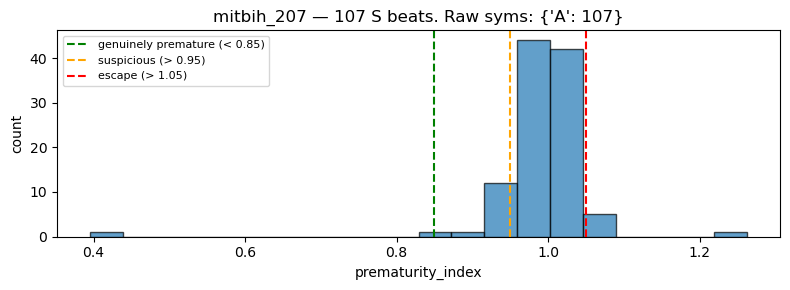


mitbih_118: 96 S beats
  Raw symbols: {'A': 96}
  Prematurity categories: {'genuinely_premature': 82, 'mildly_premature': 11, 'not_premature': 2, 'late_escape': 1}
  Mean prematurity index: 0.792 (real S should be < 0.85)
  Median prematurity index: 0.778
  Min: 0.641  Max: 1.144


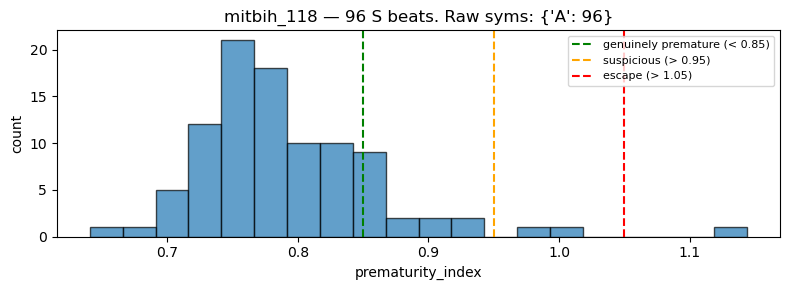


mitbih_223: 73 S beats
  Raw symbols: {'A': 72, 'a': 1}
  Prematurity categories: {'genuinely_premature': 37, 'mildly_premature': 27, 'not_premature': 6, 'late_escape': 3}
  Mean prematurity index: 0.855 (real S should be < 0.85)
  Median prematurity index: 0.848
  Min: 0.733  Max: 1.129


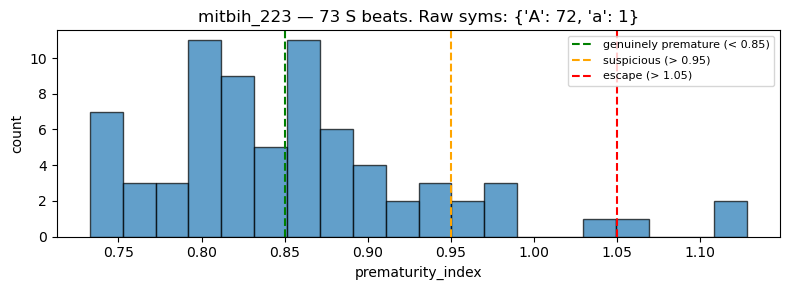


mitbih_203: 2 S beats
  Raw symbols: {'a': 2}
  Prematurity categories: {'late_escape': 1, 'genuinely_premature': 1}
  Mean prematurity index: 0.956 (real S should be < 0.85)
  Median prematurity index: 0.956
  Min: 0.786  Max: 1.126


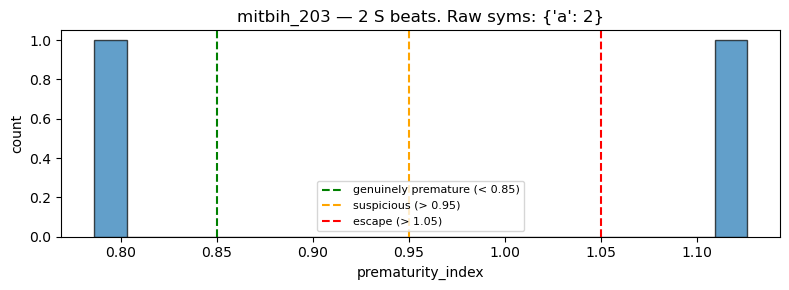


mitbih_228: 3 S beats
  Raw symbols: {'A': 3}
  Prematurity categories: {'genuinely_premature': 3}
  Mean prematurity index: 0.795 (real S should be < 0.85)
  Median prematurity index: 0.790
  Min: 0.777  Max: 0.817


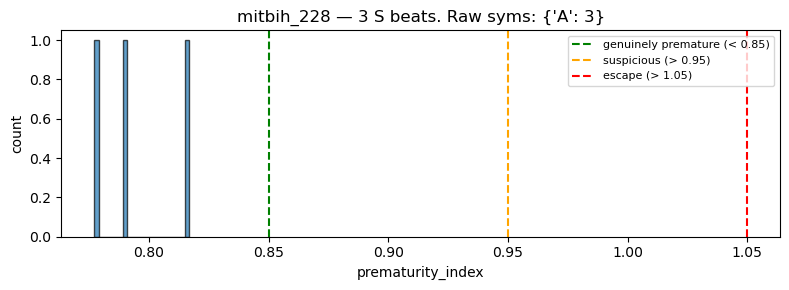


mitbih_231: 1 S beats
  Raw symbols: {'A': 1}
  Prematurity categories: {'late_escape': 1}
  Mean prematurity index: 1.092 (real S should be < 0.85)
  Median prematurity index: 1.092
  Min: 1.092  Max: 1.092


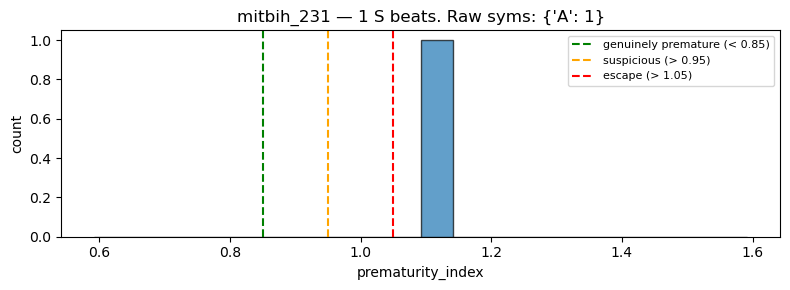

In [4]:
zero_recovery = ['mitbih_207', 'mitbih_118', 'mitbih_223',
                  'mitbih_203', 'mitbih_228', 'mitbih_231']

print(f"{'='*80}")
print(f"ZERO-RECOVERY PATIENTS: RAW ANNOTATION + PREMATURITY BREAKDOWN")
print(f"{'='*80}")

for pat in zero_recovery:
    pat_s_mask = (recs_test == pat) & (y_test_raw == 'S')
    n = int(pat_s_mask.sum())
    if n == 0:
        print(f"\n{pat}: no S beats in test")
        continue
    
    pat_indices = np.where(pat_s_mask)[0]
    pat_local = np.isin(s_indices, pat_indices)
    pat_premat = premat[pat_local]
    pat_cats = categories[pat_local]
    pat_raw = raw_syms[pat_local]
    
    print(f"\n{pat}: {n} S beats")
    print(f"  Raw symbols: {dict(Counter(pat_raw))}")
    print(f"  Prematurity categories: {dict(Counter(pat_cats))}")
    print(f"  Mean prematurity index: {pat_premat.mean():.3f} (real S should be < 0.85)")
    print(f"  Median prematurity index: {np.median(pat_premat):.3f}")
    print(f"  Min: {pat_premat.min():.3f}  Max: {pat_premat.max():.3f}")
    
    # Histogram
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(pat_premat, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(0.85, color='green', linestyle='--', label='genuinely premature (< 0.85)')
    ax.axvline(0.95, color='orange', linestyle='--', label='suspicious (> 0.95)')
    ax.axvline(1.05, color='red', linestyle='--', label='escape (> 1.05)')
    ax.set_xlabel('prematurity_index')
    ax.set_ylabel('count')
    ax.set_title(f'{pat} — {n} S beats. Raw syms: {dict(Counter(pat_raw))}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_V92}/premat_hist_{pat}.png', dpi=120, bbox_inches='tight')
    plt.show()


## Step 4 — Re-evaluate v9 on cleaned S sets

If we exclude "S" beats that are quantitatively not premature (prematurity_index > 0.95), how does v9's S F1 change?

Three evaluations:
1. **Original**: all 961 S beats (v9 baseline)
2. **Strict clean**: exclude not_premature + late_escape (keep only genuinely + mildly premature)
3. **Very strict clean**: exclude mildly_premature too (keep only genuinely premature, index < 0.85)

If S F1 jumps significantly on the cleaned sets, the model was never the problem — the labels were. The model can't learn to classify non-premature beats as "premature" because they aren't.

In [5]:
# ── Get v9 predictions on test ───────────────────────────────────────────────
gate_probs = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass = gate_probs > V9_GATE_THR
v_prob_full = np.zeros_like(gate_probs)
s_prob_full = np.zeros_like(gate_probs)
v_tmp, s_tmp = sv_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0)
v_prob_full = v_tmp.flatten(); s_prob_full = s_tmp.flatten()

y_pred_v9 = np.full(len(y_test), n_idx, dtype=int)
if gate_pass.any():
    routed = np.full(gate_pass.sum(), n_idx, dtype=int)
    v_fire = v_prob_full[gate_pass] > V9_V_THR
    routed[v_fire] = v_idx
    s_fire = (~v_fire) & (s_prob_full[gate_pass] > V9_S_THR)
    routed[s_fire] = s_idx
    y_pred_v9[gate_pass] = routed

def eval_with_s_subset(s_keep_mask, label):
    """Evaluate cascade where only a subset of S beats are counted as S.
    Beats not in s_keep_mask are removed from S (treated as not-S, relabeled to N).
    """
    y_test_clean = y_test.copy()
    y_test_raw_clean = y_test_raw.copy()
    # Relabel excluded S beats to N
    s_all_mask = y_test_raw_clean == 'S'
    exclude_mask = s_all_mask & ~s_keep_mask
    y_test_clean[exclude_mask] = n_idx
    y_test_raw_clean[exclude_mask] = 'N'
    
    cm = confusion_matrix(y_test_clean, y_pred_v9, labels=[n_idx, s_idx, v_idx])
    metrics = {'label': label}
    macro_f1 = float(f1_score(y_test_clean, y_pred_v9, average='macro', zero_division=0))
    metrics['macro_f1'] = macro_f1
    for i, cls in enumerate(le.classes_):
        tp = int(cm[i,i]); fn = int(cm[i,:].sum()-tp); fp = int(cm[:,i].sum()-tp)
        total = int(cm[i,:].sum())
        rec = tp/max(total,1); prec = tp/max(tp+fp,1)
        f1 = 2*prec*rec/max(prec+rec,1e-7)
        metrics[f'{cls}_f1'] = f1
        metrics[f'{cls}_recall'] = rec
        metrics[f'{cls}_precision'] = prec
        metrics[f'{cls}_total'] = total
    return metrics

# Build the masks
s_mask_all = y_test_raw == 'S'
premat_all = X_rr_test[:, 6]
s_premat = premat_all[s_mask_all]

# Mask 1: all S beats (original)
mask_all = np.zeros(len(y_test), dtype=bool)
mask_all[s_mask_all] = True

# Mask 2: strict clean (exclude not_premature + late_escape)
mask_strict = np.zeros(len(y_test), dtype=bool)
for idx in np.where(s_mask_all)[0]:
    pi = premat_all[idx]
    if pi < 0.95:  # genuinely + mildly premature
        mask_strict[idx] = True

# Mask 3: very strict (only genuinely premature, < 0.85)
mask_vstrict = np.zeros(len(y_test), dtype=bool)
for idx in np.where(s_mask_all)[0]:
    pi = premat_all[idx]
    if pi < 0.85:
        mask_vstrict[idx] = True

print(f"{'='*80}")
print(f"v9 RE-EVALUATION ON CLEANED S SETS")
print(f"{'='*80}")
print(f"\nS beat counts:")
print(f"  Original (all)         : {int(mask_all.sum())}")
print(f"  Strict clean (< 0.95)  : {int(mask_strict.sum())}  (excluded {int(mask_all.sum()-mask_strict.sum())})")
print(f"  Very strict (< 0.85)   : {int(mask_vstrict.sum())}  (excluded {int(mask_all.sum()-mask_vstrict.sum())})")

results = []
for mask, label in [(mask_all, 'original'), (mask_strict, 'strict_clean'),
                     (mask_vstrict, 'very_strict')]:
    m = eval_with_s_subset(mask, label)
    results.append(m)

print(f"\n{'─'*80}")
print(f"{'Set':<20} {'n_S':>6} {'S_recall':>10} {'S_prec':>8} {'S_F1':>8} {'Macro_F1':>10}")
print(f"{'─'*80}")
for r in results:
    print(f"{r['label']:<20} {r['S_total']:>6} {r['S_recall']:>10.3f} {r['S_precision']:>8.3f} "
          f"{r['S_f1']:>8.3f} {r['macro_f1']:>10.4f}")

print(f"\n{'─'*80}")
print(f"Δ from original:")
for r in results[1:]:
    d_s = r['S_f1'] - results[0]['S_f1']
    d_m = r['macro_f1'] - results[0]['macro_f1']
    print(f"  {r['label']:<20}: S F1 {d_s:+.4f}, Macro F1 {d_m:+.4f}")
print(f"{'─'*80}")

# Save
with open(f'{OUTPUTS_V92}/label_noise_analysis.json', 'w') as f:
    json.dump({
        'timestamp': datetime.now().isoformat(),
        'total_test_S': int(s_mask_all.sum()),
        'prematurity_categories': dict(Counter(categories)),
        'raw_symbol_counts': dict(raw_sym_counts),
        'cleaned_evaluations': results,
    }, f, indent=2, default=str)
print(f"\nSaved: {OUTPUTS_V92}/label_noise_analysis.json")


v9 RE-EVALUATION ON CLEANED S SETS

S beat counts:
  Original (all)         : 961
  Strict clean (< 0.95)  : 566  (excluded 395)
  Very strict (< 0.85)   : 451  (excluded 510)

────────────────────────────────────────────────────────────────────────────────
Set                     n_S   S_recall   S_prec     S_F1   Macro_F1
────────────────────────────────────────────────────────────────────────────────
original                961      0.135    0.233    0.171     0.5806
strict_clean            566      0.154    0.156    0.155     0.5759
very_strict             451      0.160    0.129    0.143     0.5720

────────────────────────────────────────────────────────────────────────────────
Δ from original:
  strict_clean        : S F1 -0.0164, Macro F1 -0.0046
  very_strict         : S F1 -0.0284, Macro F1 -0.0085
────────────────────────────────────────────────────────────────────────────────

Saved: outputs_v92/label_noise_analysis.json


## Step 5 — Per-patient raw symbol deep dive

For each test patient, show: how many S beats, what raw symbols, and what fraction are quantitatively premature. This is the definitive view of whether the S problem is a data problem.

In [6]:
print(f"{'='*100}")
print(f"ALL TEST PATIENTS — S BEAT ANNOTATION QUALITY")
print(f"{'='*100}")
print(f"{'Patient':<14} {'n_S':>5} {'raw_syms':>30} {'prem<0.85':>10} {'0.85-0.95':>10} {'0.95-1.05':>10} {'>1.05':>7} {'%suspicious':>13}")
print(f"{'-'*100}")

total_suspicious = 0
total_s = 0
for rec_tag in sorted(set(recs_test)):
    pat_s_mask = (recs_test == rec_tag) & (y_test_raw == 'S')
    n = int(pat_s_mask.sum())
    if n == 0: continue
    
    pat_indices = np.where(pat_s_mask)[0]
    pat_premat = X_rr_test[pat_indices, 6]
    pat_raw = raw_sym_array[pat_indices]
    
    n_genuinely = int(np.sum(pat_premat < 0.85))
    n_mildly = int(np.sum((pat_premat >= 0.85) & (pat_premat < 0.95)))
    n_not_prem = int(np.sum((pat_premat >= 0.95) & (pat_premat <= 1.05)))
    n_escape = int(np.sum(pat_premat > 1.05))
    n_suspicious = n_not_prem + n_escape
    pct_suspicious = n_suspicious / n * 100 if n > 0 else 0
    
    raw_str = str(dict(Counter(pat_raw)))
    print(f"{rec_tag:<14} {n:>5} {raw_str:>30} {n_genuinely:>10} {n_mildly:>10} {n_not_prem:>10} {n_escape:>7} {pct_suspicious:>12.1f}%")
    
    total_suspicious += n_suspicious
    total_s += n

print(f"{'-'*100}")
print(f"{'TOTAL':<14} {total_s:>5} {'':>30} {'':>10} {'':>10} {'':>10} {'':>7} {total_suspicious/total_s*100:>12.1f}%")
print(f"{'='*100}")

print(f"\n{'='*100}")
print(f"VERDICT")
print(f"{'='*100}")
pct = total_suspicious / total_s * 100
if pct > 30:
    print(f"  {total_suspicious}/{total_s} ({pct:.1f}%) of test S beats are NOT premature (prematurity_index > 0.95)")
    print(f"  → LABEL NOISE IS A MAJOR FACTOR. The 'S' class is contaminated with non-ectopic beats.")
    print(f"  → The model cannot learn to classify non-premature beats as 'premature' because they aren't.")
    print(f"  → Fix: clean the S annotations (exclude non-premature beats) before any more model experiments.")
elif pct > 15:
    print(f"  {total_suspicious}/{total_s} ({pct:.1f}%) of test S beats are NOT premature")
    print(f"  → Label noise is moderate. Cleaning will help but isn't the whole story.")
else:
    print(f"  {total_suspicious}/{total_s} ({pct:.1f}%) of test S beats are NOT premature")
    print(f"  → Label noise is minimal. The S problem is a model/data-representation issue.")


ALL TEST PATIENTS — S BEAT ANNOTATION QUALITY
Patient          n_S                       raw_syms  prem<0.85  0.85-0.95  0.95-1.05   >1.05   %suspicious
----------------------------------------------------------------------------------------------------
mitbih_101         3                       {'A': 3}          2          1          0       0          0.0%
mitbih_108         4                       {'A': 4}          4          0          0       0          0.0%
mitbih_112         2                       {'A': 2}          2          0          0       0          0.0%
mitbih_114        12              {'J': 2, 'A': 10}          5          3          1       3         33.3%
mitbih_116         1                       {'A': 1}          1          0          0       0          0.0%
mitbih_118        96                      {'A': 96}         82         11          2       1          3.1%
mitbih_201       128     {'a': 97, 'A': 30, 'J': 1}        119          8          0       1          0.

## Step 6 — Same analysis on the TRAIN set

Label noise in test is bad for evaluation. Label noise in train is worse — it actively teaches the model wrong patterns. If the training S set is also contaminated with non-premature beats, the model learns "S = any beat with this morphology" rather than "S = premature beat with this morphology." That would explain why it can't distinguish S from N at test time.

In [7]:
# ── Same analysis on train set ───────────────────────────────────────────────
train_mask = ~np.isin(recs_all, list(test_recs_set)) & ~np.isin(recs_all, [f'mitbih_{r}' for r in MITBIH_VAL_RECORDS])
X_rr_train_check = X_rr_all[train_mask]
y_train_raw_check = y_raw_all[train_mask]
recs_train_check = recs_all[train_mask]

# Pull raw annotations for train records
print("Pulling raw annotation symbols for train S beats...")
rec_raw_syms_train = {}
for rec_id in MITBIH_TRAIN_RECORDS:
    rec_str = str(rec_id)
    rec_tag = f'mitbih_{rec_str}'
    try:
        ann = wfdb.rdann(f'{MITBIH_PATH}/{rec_str}', 'atr')
        syms = [sym for sym in ann.symbol if sym in BEAT_MAP and BEAT_MAP[sym] == 'S']
        if syms:
            rec_raw_syms_train[rec_tag] = syms
    except: pass

# Also pull SVDB annotations
svdb_recs_train = set(recs_train_check) - {f'mitbih_{r}' for r in MITBIH_TRAIN_RECORDS}
for rec_tag in svdb_recs_train:
    rec_id = rec_tag.replace('svdb_', '')
    try:
        ann = wfdb.rdann(f'{find_dir(BASE, "mit-bih-supraventricular-arrhythmia-database-1.0.0", "svdb")}/{rec_id}', 'atr')
        syms = [sym for sym in ann.symbol if sym in BEAT_MAP and BEAT_MAP[sym] == 'S']
        if syms:
            rec_raw_syms_train[rec_tag] = syms
    except: pass

# Match raw symbols to train array
raw_sym_train = np.array([''] * len(y_train_raw_check), dtype=object)
for rec_tag in set(recs_train_check):
    if rec_tag not in rec_raw_syms_train: continue
    syms = rec_raw_syms_train[rec_tag]
    rec_s_mask = (recs_train_check == rec_tag) & (y_train_raw_check == 'S')
    rec_s_indices = np.where(rec_s_mask)[0]
    for i, idx in enumerate(rec_s_indices):
        if i < len(syms):
            raw_sym_train[idx] = syms[i]

# Analyze
s_train_mask = y_train_raw_check == 'S'
premat_train = X_rr_train_check[s_train_mask, 6]
raw_syms_train_s = raw_sym_train[s_train_mask]

print(f"\n{'='*70}")
print(f"TRAIN SET S BEAT ANALYSIS")
print(f"{'='*70}")
print(f"Total train S beats: {int(s_train_mask.sum())}")
print(f"\nRaw symbol counts: {dict(Counter(raw_syms_train_s))}")

cats_train = np.array([premat_category(p) for p in premat_train])
print(f"\nPrematurity categories:")
for cat in ['genuinely_premature', 'mildly_premature', 'not_premature', 'late_escape']:
    n = int(np.sum(cats_train == cat))
    print(f"  {cat:<25}: {n:5d}  ({n/len(cats_train)*100:.1f}%)")

n_suspicious_train = int(np.sum(cats_train == 'not_premature') + np.sum(cats_train == 'late_escape'))
print(f"\n  Suspicious (non-premature): {n_suspicious_train}/{len(cats_train)} = {n_suspicious_train/len(cats_train)*100:.1f}%")

# Per-patient breakdown for train
print(f"\n{'='*90}")
print(f"TRAIN PATIENTS — S BEAT ANNOTATION QUALITY (top 10 by S count)")
print(f"{'='*90}")
print(f"{'Patient':<14} {'n_S':>5} {'raw_syms':>25} {'prem<0.85':>10} {'0.85-0.95':>10} {'0.95-1.05':>10} {'>1.05':>7}")
print(f"{'-'*90}")

pat_data = []
for rec_tag in sorted(set(recs_train_check)):
    pat_s_mask = (recs_train_check == rec_tag) & (y_train_raw_check == 'S')
    n = int(pat_s_mask.sum())
    if n == 0: continue
    pat_indices = np.where(pat_s_mask)[0]
    pat_premat = X_rr_train_check[pat_indices, 6]
    pat_raw = raw_sym_train[pat_indices]
    n_g = int(np.sum(pat_premat < 0.85))
    n_m = int(np.sum((pat_premat >= 0.85) & (pat_premat < 0.95)))
    n_np = int(np.sum((pat_premat >= 0.95) & (pat_premat <= 1.05)))
    n_e = int(np.sum(pat_premat > 1.05))
    pat_data.append((rec_tag, n, pat_raw, n_g, n_m, n_np, n_e))

pat_data.sort(key=lambda x: -x[1])
for rec_tag, n, pat_raw, n_g, n_m, n_np, n_e in pat_data[:15]:
    raw_str = str(dict(Counter(pat_raw)))
    print(f"{rec_tag:<14} {n:>5} {raw_str:>25} {n_g:>10} {n_m:>10} {n_np:>10} {n_e:>7}")

print(f"\n{'='*70}")
print(f"TRAIN LABEL NOISE VERDICT")
print(f"{'='*70}")
pct_train = n_suspicious_train / len(cats_train) * 100
if pct_train > 20:
    print(f"  {pct_train:.1f}% of train S beats are NOT premature")
    print(f"  → TRAIN LABEL NOISE IS ACTIVE. The model is being taught wrong patterns.")
    print(f"  → The model learns 'S = this morphology' instead of 'S = premature + this morphology'")
    print(f"  → This is why it can't distinguish S from N at test time: many N beats have the same morphology")
    print(f"  → Fix: clean train S annotations before retraining. This is more important than any model change.")
else:
    print(f"  {pct_train:.1f}% of train S beats are NOT premature — train noise is manageable")


Pulling raw annotation symbols for train S beats...

TRAIN SET S BEAT ANALYSIS
Total train S beats: 13889

Raw symbol counts: {'A': 1685, 'a': 10, 'J': 10, 'S': 12184}

Prematurity categories:
  genuinely_premature      :  8473  (61.0%)
  mildly_premature         :  2131  (15.3%)
  not_premature            :  2459  (17.7%)
  late_escape              :   826  (5.9%)

  Suspicious (non-premature): 3285/13889 = 23.7%

TRAIN PATIENTS — S BEAT ANNOTATION QUALITY (top 10 by S count)
Patient          n_S                  raw_syms  prem<0.85  0.85-0.95  0.95-1.05   >1.05
------------------------------------------------------------------------------------------
svdb_865        1818               {'S': 1818}        132         37       1133     516
mitbih_232      1382               {'A': 1382}        686         19        636      41
svdb_822         658                {'S': 658}          1        590         65       2
svdb_869         632                {'S': 632}        507         83       

## Step 7 — Summary and what this means

This notebook replaced v9.1's failed visual categorization (which required cardiology expertise you don't have) with a quantitative analysis using the RR features we already computed.

### What the RR features tell us objectively

A supraventricular ectopic beat (S) is **by definition premature**. The `prematurity_index` (rr_prev / rr_mean_5) measures this directly:
- `< 0.85` = genuinely premature (real S)
- `> 0.95` = not premature (suspicious — likely mislabeled or junctional escape)

No visual inspection needed. No cardiology expertise needed. The RR interval is an objective measurement.

### What to do with the results

**If label noise is high (> 30% non-premature):**
- The S problem is largely a data problem, not a model problem
- Clean the S annotations (exclude non-premature beats from both train and test)
- Re-evaluate v9 on the cleaned test set
- If S F1 jumps, the model was never the problem
- Retrain on cleaned train set — the model will finally learn "S = premature + morphology" instead of "S = morphology"

**If label noise is moderate (15-30%):**
- Cleaning will help but isn't the whole story
- Also investigate: the AAMI mapping of junctional beats (J) to S class is debatable
- Consider excluding J beats from S entirely (treat as separate class or merge with N)

**If label noise is low (< 15%):**
- The S problem is genuinely a model/data-representation issue
- The model can't distinguish S from N even when the S beats are genuinely premature
- Look at window size (v9.1 C1 showed gate S-recall improved at 200 samples)
- Look at the SV head's N-rejection (the v9.1 B2a decoupled N mining approach, but with better threshold tuning)


In [8]:
print(f"{'='*80}")
print(f"v9.2 QUANTITATIVE LABEL-NOISE ANALYSIS — COMPLETE")
print(f"{'='*80}")
print(f"\nFiles produced:")
print(f"  {OUTPUTS_V92}/label_noise_analysis.json")
print(f"  {OUTPUTS_V92}/premat_hist_*.png (per zero-recovery patient)")
print(f"\nNext steps depend on the verdict above:")
print(f"  - If label noise is high: clean annotations, re-evaluate v9, retrain on cleaned data")
print(f"  - If label noise is low: the S problem is a model issue, pursue window size + SV head fixes")
print(f"  - Either way: do NOT pursue visual categorization — the RR features are more objective")
print(f"    than any human looking at compressed ECG thumbnails")


v9.2 QUANTITATIVE LABEL-NOISE ANALYSIS — COMPLETE

Files produced:
  outputs_v92/label_noise_analysis.json
  outputs_v92/premat_hist_*.png (per zero-recovery patient)

Next steps depend on the verdict above:
  - If label noise is high: clean annotations, re-evaluate v9, retrain on cleaned data
  - If label noise is low: the S problem is a model issue, pursue window size + SV head fixes
  - Either way: do NOT pursue visual categorization — the RR features are more objective
    than any human looking at compressed ECG thumbnails
